In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

# Paths
TRAIN_IMAGES = "/teamspace/studios/this_studio/cell_dataset/train/train_images"
TRAIN_MASKS  = "/teamspace/studios/this_studio/cell_dataset/train/train_masks"
TEST_IMAGES  = "/teamspace/studios/this_studio/cell_dataset/test/test_images"

print("✅ Imports done!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")

✅ Imports done!
PyTorch version: 2.8.0+cu128
GPU available:   False


In [2]:
# Convert: RGB color → class ID (0, 1, 2, 3, 4)
# label encoding

COLOR_TO_CLASS = {
    (0,   0,   0):   0,  # Background  — most common\
    (255, 255, 0):   1,  
    (255, 0,   0):   2,  
    (0,   255, 0):   3,  
    (0,   0,   255): 4,  
}

# Reverse mapping
CLASS_TO_COLOR = {v: k for k, v in COLOR_TO_CLASS.items()}

NUM_CLASSES = len(COLOR_TO_CLASS)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Color → Class mapping: {COLOR_TO_CLASS}")

Number of classes: 5
Color → Class mapping: {(0, 0, 0): 0, (255, 255, 0): 1, (255, 0, 0): 2, (0, 255, 0): 3, (0, 0, 255): 4}


In [5]:
def rgb_to_mask(mask_rgb):
    """
    Convert an RGB mask image to a 2D class label map.
    Input:  numpy array of shape (H, W, 3) — RGB mask
    Output: numpy array of shape (H, W)    — class IDs (0-4)
    """
    H, W, _ = mask_rgb.shape
    # Start with all zeros (Background class)
    label_map = np.zeros((H, W), dtype=np.int64)

    for color, class_id in COLOR_TO_CLASS.items():
        # Find all pixels that exactly match this color
        # np.all(..., axis=-1) checks all 3 channels simultaneously
        match = np.all(mask_rgb == np.array(color), axis=-1)
        label_map[match] = class_id

    return label_map

def mask_to_rgb(label_map):
    """
    Convert a 2D class label map back to an RGB mask.
    Used for visualization of model predictions.
    """
    H, W = label_map.shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)

    for class_id, color in CLASS_TO_COLOR.items():
        rgb[label_map == class_id] = color

    return rgb

sample_mask = np.array(Image.open(
    os.path.join(TRAIN_MASKS, sorted(os.listdir(TRAIN_MASKS))[0])
))
label_map = rgb_to_mask(sample_mask)

print(f"Input mask shape:  {sample_mask.shape}")   
print(f"Output label shape:{label_map.shape}")     
print(f"Unique class IDs:  {np.unique(label_map)}")

Input mask shape:  (512, 512, 3)
Output label shape:(512, 512)
Unique class IDs:  [0 2 3 4]


In [6]:
# Used 90/10

all_images = sorted(os.listdir(TRAIN_IMAGES))
all_masks  = sorted(os.listdir(TRAIN_MASKS))

train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    all_images, all_masks,
    test_size=0.1,        
    random_state=42       # reproducibility
)

print(f"Total images:      {len(all_images)}")
print(f"Training images:   {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")
print(f"\nValidation files:")
for f in val_imgs:
    print(f"  {f}")

Total images:      108
Training images:   97
Validation images: 11

Validation files:
  train_2_1.png
  train_12_2.png
  train_11_0.png
  train_3_3.png
  train_24_2.png
  train_25_3.png
  train_17_2.png
  train_20_1.png
  train_6_3.png
  train_12_3.png
  train_3_1.png


In [8]:
# Data augmentation to artificially increases our dataset size
# IMPORTANT RULE: Whatever transformation we apply to the image
# we MUST apply the exact same transformation to its mask
# If we flip the image, the mask must be flipped too
# Otherwise the mask won't align with the image anymore

def augment(image, mask):
    # Random horizontal flip — 50% chance
    if random.random() > 0.5:
        image = TF.hflip(image)
        mask  = TF.hflip(mask)

    # Random vertical flip — 50% chance
    if random.random() > 0.5:
        image = TF.vflip(image)
        mask  = TF.vflip(mask)

    # Random rotation — 0, 90, 180, or 270 degrees
    # We use only 90-degree multiples to avoid black border artifacts
    angle = random.choice([0, 90, 180, 270])
    image = TF.rotate(image, angle)
    mask  = TF.rotate(mask,  angle)

    # Random crop and resize back to 512x512
    i, j, h, w = torchvision_random_crop_params(image, scale=(0.7, 1.0))
    image = TF.resized_crop(image, i, j, h, w, size=(512, 512),
                             interpolation=TF.InterpolationMode.BILINEAR)
    mask  = TF.resized_crop(mask,  i, j, h, w, size=(512, 512),
                             interpolation=TF.InterpolationMode.NEAREST)
    # IMPORTANT: Image uses BILINEAR interpolation (smooth pixel blending)

    # ── Color Transforms (applied to image ONLY) ─────────────────────
    # Random brightness and contrast adjustment
    # Simulates different staining intensities
    image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.8, 1.2))
    image = TF.adjust_contrast(image,   contrast_factor=random.uniform(0.8, 1.2))

    return image, mask

def torchvision_random_crop_params(img, scale=(0.7, 1.0)):
    """Helper to compute random crop parameters"""
    width, height = img.size
    area = height * width
    target_area = random.uniform(scale[0], scale[1]) * area
    aspect_ratio = width / height
    w = int(round((target_area * aspect_ratio) ** 0.5))
    h = int(round((target_area / aspect_ratio) ** 0.5))
    w = min(w, width)
    h = min(h, height)
    i = random.randint(0, height - h)
    j = random.randint(0, width  - w)
    return i, j, h, w

print("Augmentation function defined!")

Augmentation function defined!


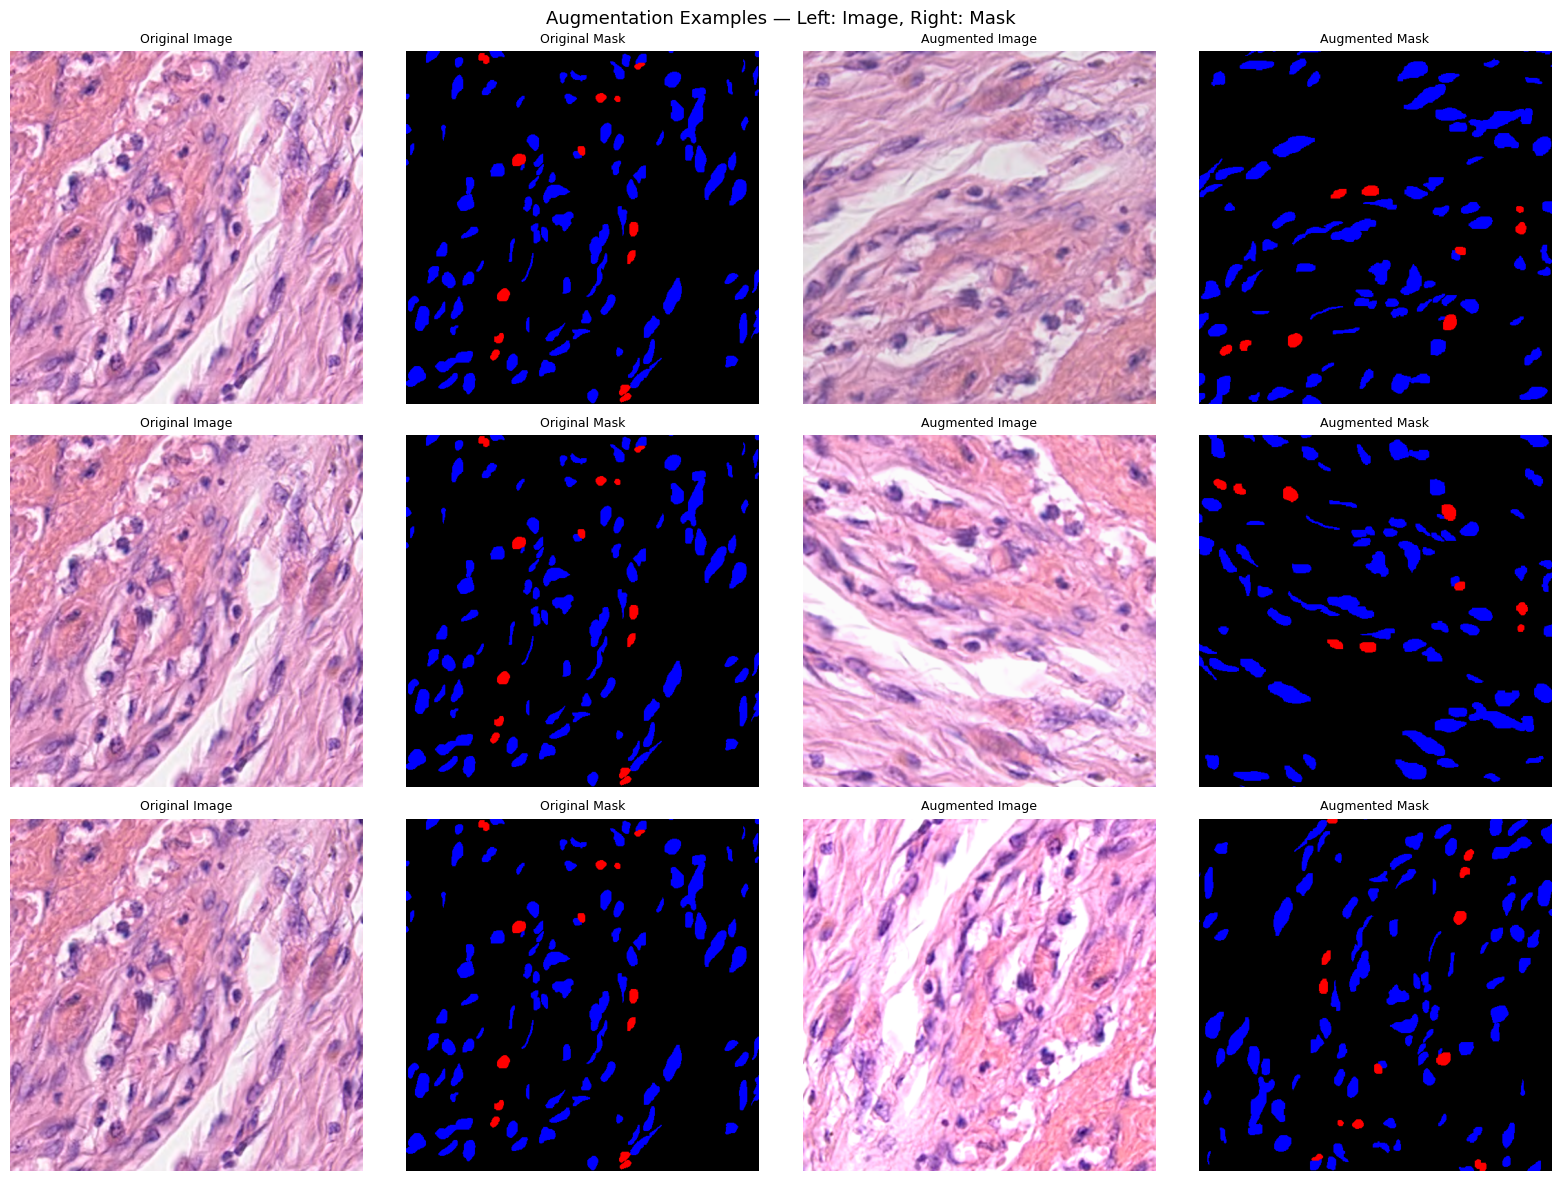

Saved to ../results/augmentation_examples.png


In [9]:
# Always visualize augmentation before training
# to confirm it looks realistic and masks stay aligned

sample_img  = Image.open(os.path.join(TRAIN_IMAGES, train_imgs[0]))
sample_mask = Image.open(os.path.join(TRAIN_MASKS,  train_msks[0]))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Augmentation Examples — Left: Image, Right: Mask", fontsize=13)

for row in range(3):
    aug_img, aug_mask = augment(sample_img, sample_mask)

    axes[row, 0].imshow(sample_img)
    axes[row, 0].set_title("Original Image", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(sample_mask)
    axes[row, 1].set_title("Original Mask", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(aug_img)
    axes[row, 2].set_title("Augmented Image", fontsize=9)
    axes[row, 2].axis("off")

    axes[row, 3].imshow(aug_mask)
    axes[row, 3].set_title("Augmented Mask", fontsize=9)
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("../results/augmentation_examples.png", dpi=150)
plt.show()
print("Saved to ../results/augmentation_examples.png")

In [10]:
class CellSegmentationDataset(Dataset):
    """
    PyTorch Dataset for CoNSeP cell segmentation.
    
    A Dataset class must implement 3 methods:
    - __init__  : store file paths and settings
    - __len__   : return total number of samples
    - __getitem__: load and return one sample by index
    
    The DataLoader calls __getitem__ repeatedly to build batches.
    """
    def __init__(self, image_dir, mask_dir, filenames, is_train=True):

        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.filenames = filenames
        self.is_train  = is_train

    def __len__(self):
        # Returns total number of samples
        return len(self.filenames)

    def __getitem__(self, idx):
        """
        Load one image-mask pair by index.
        This is called by DataLoader for every sample in every batch.
        """
        fname = self.filenames[idx]

        # ── Load image and mask ───────────────────────────────────────
        image = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        mask  = Image.open(os.path.join(self.mask_dir,  fname)).convert("RGB")

        # ── Apply augmentation (training only) ────────────────────────
        # Validation images are never augmented — we need clean unmodified
        # images to get an honest measure of model performance
        if self.is_train:
            image, mask = augment(image, mask)

        # ── Convert image to tensor ───────────────────────────────────
        # Neural networks expect tensors, not PIL Images
        # ToTensor: converts (H, W, C) uint8 [0-255] → (C, H, W) float [0-1]
        # Note: we divide by 255 automatically — this is basic normalization
        image = TF.to_tensor(image)

        # ── Normalize image ───────────────────────────────────────────
        # Subtract mean and divide by std per channel
        # These are standard ImageNet values — commonly used even for
        # medical images since they stabilize training
        image = TF.normalize(image,
                             mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])

        # ── Convert mask to class label map ───────────────────────────
        # RGB mask (H, W, 3) → class IDs (H, W) with values 0-4
        # The model outputs one score per class per pixel
        # so we need integer class IDs not RGB colors
        mask = np.array(mask)
        mask = rgb_to_mask(mask)

        # Convert to PyTorch tensor — LongTensor required for CrossEntropyLoss
        mask = torch.from_numpy(mask).long()

        return image, mask

In [11]:
# Create Dataset objects for train and validation
train_dataset = CellSegmentationDataset(
    image_dir=TRAIN_IMAGES,
    mask_dir=TRAIN_MASKS,
    filenames=train_imgs,
    is_train=True    # augmentation ON
)

val_dataset = CellSegmentationDataset(
    image_dir=TRAIN_IMAGES,
    mask_dir=TRAIN_MASKS,
    filenames=val_imgs,
    is_train=False   # augmentation OFF
)

# DataLoader wraps the Dataset and handles:
# - Batching: groups multiple samples together
# - Shuffling: randomizes order each epoch (training only)
# - num_workers: parallel loading for speed
train_loader = DataLoader(
    train_dataset,
    batch_size=4,     # 4 images at once — safe for 512x512 on T4 GPU
    shuffle=True,     # shuffle training data every epoch
    num_workers=2,    # parallel workers for faster loading
    pin_memory=True   # speeds up CPU→GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,    # never shuffle validation — order doesn't matter
    num_workers=2,
    pin_memory=True
)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Batch size:         4")
print(f"Train samples:      {len(train_dataset)}")
print(f"Val samples:        {len(val_dataset)}")

Training batches:   25
Validation batches: 3
Batch size:         4
Train samples:      97
Val samples:        11


In [12]:
# Always verify one batch before training
# This catches shape mismatches, dtype errors, and other issues early
images, masks = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
# Expected: (4, 3, 512, 512) — batch x channels x height x width

print(f"Mask batch shape:  {masks.shape}")
# Expected: (4, 512, 512) — batch x height x width (no channel dim!)

print(f"Image dtype:       {images.dtype}")
# Expected: torch.float32

print(f"Mask dtype:        {masks.dtype}")
# Expected: torch.int64 (LongTensor — required by CrossEntropyLoss)

print(f"Image value range: {images.min():.2f} – {images.max():.2f}")
# Expected: roughly -2 to 2 after normalization

print(f"Mask unique values:{torch.unique(masks)}")

print("\nDataLoader verified!")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([4, 3, 512, 512])
Mask batch shape:  torch.Size([4, 512, 512])
Image dtype:       torch.float32
Mask dtype:        torch.int64
Image value range: -2.12 – 2.57
Mask unique values:tensor([0, 2, 3, 4])

DataLoader verified!


In [14]:
print("=" * 45)
print("PREPROCESSING COMPLETE")
print("=" * 45)
print(f"  Train samples:     {len(train_dataset)}")
print(f"  Val samples:       {len(val_dataset)}")
print(f"  Batch size:        4")
print(f"  Image shape:       (3, 512, 512) — float32")
print(f"  Mask shape:        (512, 512)    — int64")
print(f"  Augmentation:      Flip, Rotate, Crop, Brightness")
print(f"  Normalization:     ImageNet mean/std")
print(f"  Color→Class:       RGB → 0,1,2,3,4")


PREPROCESSING COMPLETE
  Train samples:     97
  Val samples:       11
  Batch size:        4
  Image shape:       (3, 512, 512) — float32
  Mask shape:        (512, 512)    — int64
  Augmentation:      Flip, Rotate, Crop, Brightness
  Normalization:     ImageNet mean/std
  Color→Class:       RGB → 0,1,2,3,4
